In [23]:
import pandas as pd #for handling data 
import numpy as np #for numerical calculations 
import matplotlib.pyplot as plt #for data visualization
import seaborn as sns 

from sklearn.model_selection import train_test_split 
from sklearn.linear_model import LinearRegression

#evaluation metrics
from sklearn.metrics import mean_absolute_error 
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score


In [24]:
# read the dataset
df= pd.read_csv(r"C:\Users\sohai\Downloads\Advertising.csv")
print("First 5 rows")
print(df.head())

First 5 rows
   Unnamed: 0     TV  Radio  Newspaper  Sales
0           1  230.1   37.8       69.2   22.1
1           2   44.5   39.3       45.1   10.4
2           3   17.2   45.9       69.3    9.3
3           4  151.5   41.3       58.5   18.5
4           5  180.8   10.8       58.4   12.9


In [5]:
print("Dataset Information ")
print(df.info())

Dataset Information 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   TV          200 non-null    float64
 2   Radio       200 non-null    float64
 3   Newspaper   200 non-null    float64
 4   Sales       200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB
None


In [6]:
print("Statistical Summary ")
print(df.describe())

Statistical Summary 
       Unnamed: 0          TV       Radio   Newspaper       Sales
count  200.000000  200.000000  200.000000  200.000000  200.000000
mean   100.500000  147.042500   23.264000   30.554000   14.022500
std     57.879185   85.854236   14.846809   21.778621    5.217457
min      1.000000    0.700000    0.000000    0.300000    1.600000
25%     50.750000   74.375000    9.975000   12.750000   10.375000
50%    100.500000  149.750000   22.900000   25.750000   12.900000
75%    150.250000  218.825000   36.525000   45.100000   17.400000
max    200.000000  296.400000   49.600000  114.000000   27.000000


In [8]:
#data cleaning 
df.drop("Unnamed: 0",axis=1,inplace=True )
print("Columns after cleaning")
print(df.columns)

Columns after cleaning
Index(['TV', 'Radio', 'Newspaper', 'Sales'], dtype='object')


In [11]:
#check for missing values
print("Missing values")
print(df.isnull().sum())

Missing values
TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64


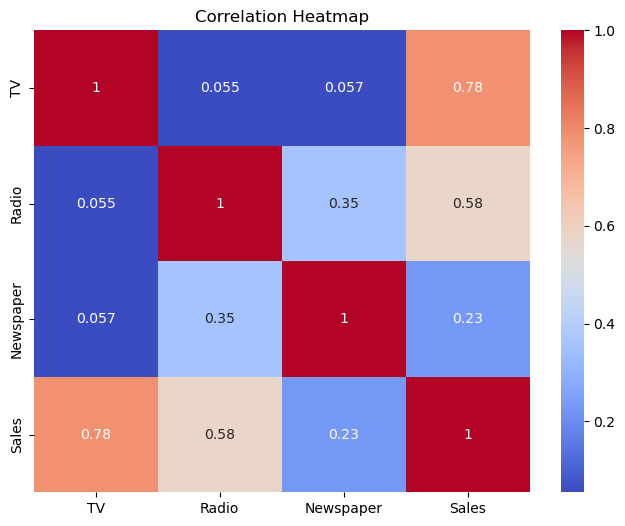

In [14]:
#perform EDA 
#correlation heatmap 
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(),annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap")
plt.show()

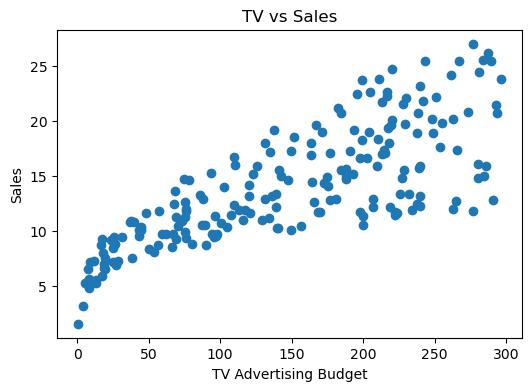

In [15]:
#visualize relationships

# TV vs Sales
plt.figure(figsize=(6,4))
plt.scatter(df["TV"], df["Sales"])

plt.xlabel("TV Advertising Budget")
plt.ylabel("Sales")

plt.title("TV vs Sales")
plt.show()

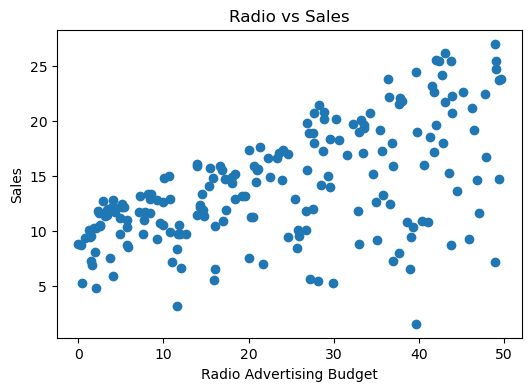

In [16]:
#Radio vs Sales

plt.figure(figsize=(6,4))
plt.scatter(df["Radio"], df["Sales"])

plt.xlabel("Radio Advertising Budget")
plt.ylabel("Sales")

plt.title("Radio vs Sales")
plt.show()

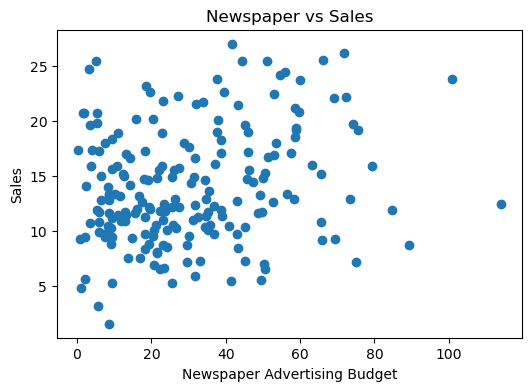

In [17]:
# Newspaper vs Sales

plt.figure(figsize=(6,4))
plt.scatter(df["Newspaper"], df["Sales"])

plt.xlabel("Newspaper Advertising Budget")
plt.ylabel("Sales")

plt.title("Newspaper vs Sales")
plt.show()

In [18]:
# defining featurres and target 
X = df[["TV", "Radio", "Newspaper"]]
y = df["Sales"]

In [25]:
# train and test split
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.20, random_state=42)

#train the model 
model = LinearRegression()
model.fit(X_train, y_train)

print("Model Training Completed")

Model Training Completed


In [26]:
# make predictions 
y_pred = model.predict(X_test)

In [27]:
# model evaluation
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Model Evaluation")
print("----------------------")
print("MAE:", mae)
print("MSE:", mse)
print("R² Score:", r2)

Model Evaluation
----------------------
MAE: 1.4607567168117606
MSE: 3.1740973539761055
R² Score: 0.899438024100912


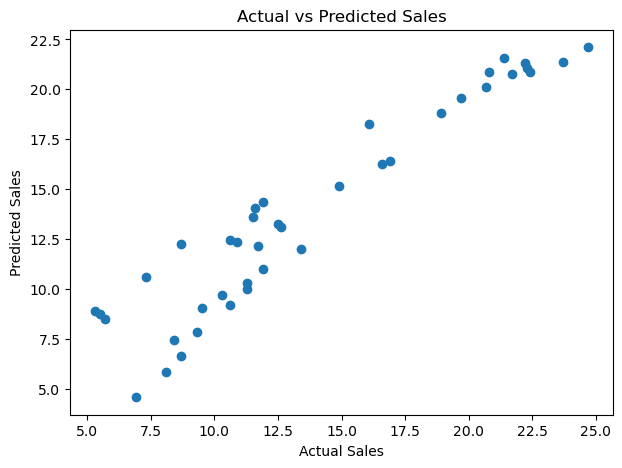

In [28]:
# Actual vs Predicted graph 
plt.figure(figsize=(7,5))
plt.scatter(y_test, y_pred)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")

plt.title("Actual vs Predicted Sales")
plt.show()


In [29]:
# Feature Importance 
coefficients = pd.DataFrame({ "Feature": X.columns, "Coefficient": model.coef_})

print("Feature Impact on Sales")
print(coefficients)


Feature Impact on Sales
     Feature  Coefficient
0         TV     0.044730
1      Radio     0.189195
2  Newspaper     0.002761


In [30]:
#Sample prediction
sample_ad = pd.DataFrame({ "TV": [150], "Radio": [25], "Newspaper": [30]})
predicted_sales = model.predict(sample_ad)

print("\nPredicted Sales:")
print(predicted_sales[0])


Predicted Sales:
14.501204744530506
